In [59]:
import numpy as np
import pandas as pd
import sklearn

In [2]:
df = pd.read_csv("college_student_placement_dataset.csv")

In [60]:
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
# import matplotlib.pyplot as plt
print("Seaborn:", sns.__version__)

print(plt.matplotlib.__version__)

numpy 2.3.5
pandas 2.3.3
Scikit-learn: 1.7.2
Seaborn: 0.13.2
3.10.6


In [3]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [4]:
df.shape

(10000, 10)

In [5]:
df.isnull().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
pd.crosstab(
    df["IQ"],
    df["Placement"]
)

Placement,No,Yes
IQ,,
41,1,0
42,1,0
44,1,0
45,1,0
51,3,0
...,...,...
148,0,1
150,0,1
152,1,0


In [8]:
import matplotlib.pyplot as plt

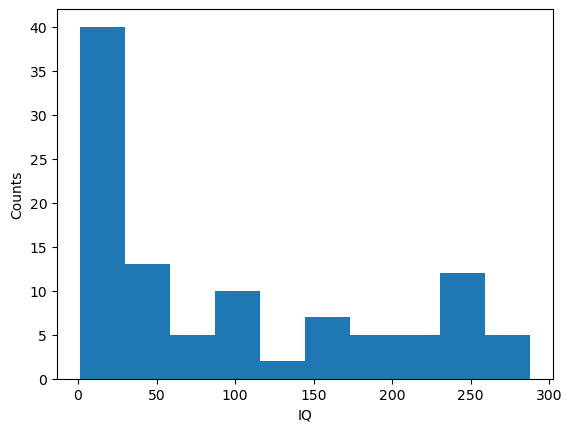

In [9]:
df["IQ"].value_counts().plot(kind = "hist")
plt.xlabel("IQ")
plt.ylabel("Counts")
plt.show()

In [10]:
pd.crosstab(
    df["Academic_Performance"],
    df["Placement"],
    normalize="index"

)*100

Placement,No,Yes
Academic_Performance,,
1,82.346833,17.653167
2,83.216080,16.783920
3,82.341070,17.658930
4,81.274900,18.725100
5,83.880903,16.119097
6,85.151515,14.848485
7,85.491723,14.508277
8,83.121951,16.878049
9,83.485309,16.514691


In [11]:
pd.crosstab(
    df["CGPA"],
    df["Placement"]
    # normalize="index"
)

Placement,No,Yes
CGPA,,
4.54,1,0
4.56,1,0
4.57,1,0
4.58,0,1
4.59,2,1
...,...,...
10.41,1,0
10.42,2,0
10.44,1,0


In [12]:
pd.crosstab(
    df["Internship_Experience"], 
    df["Placement"],
    normalize="index"
)*100

Placement,No,Yes
Internship_Experience,,
No,83.233930,16.766070
Yes,83.678103,16.321897


In [13]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [14]:
col = ['CGPA', 'Academic_Performance', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed']

In [15]:
import matplotlib.pyplot as plt

In [16]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [17]:
df.drop("College_ID", axis = 1, inplace = True)

In [18]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No


In [19]:
df.dtypes

IQ                          int64
Prev_Sem_Result           float64
CGPA                      float64
Academic_Performance        int64
Internship_Experience      object
Extra_Curricular_Score      int64
Communication_Skills        int64
Projects_Completed          int64
Placement                  object
dtype: object

In [20]:
df["Internship_Experience"] = df["Internship_Experience"].map({
    "Yes" : 1,
    "No" : 0
})

In [21]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,No
1,97,5.52,5.37,8,0,7,8,0,No
2,109,5.36,5.83,9,0,3,1,1,No
3,122,5.47,5.75,6,1,1,6,1,No
4,96,7.91,7.69,7,0,8,10,2,No


In [22]:
df["Placement"].value_counts()

Placement
No     8341
Yes    1659
Name: count, dtype: int64

In [23]:
df["Placement"] = df["Placement"].map({
    "No" : 0,
    "Yes" : 1})

In [24]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0


In [25]:
df.dtypes

IQ                          int64
Prev_Sem_Result           float64
CGPA                      float64
Academic_Performance        int64
Internship_Experience       int64
Extra_Curricular_Score      int64
Communication_Skills        int64
Projects_Completed          int64
Placement                   int64
dtype: object

In [26]:
df.isnull().sum()

IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
numeric_df = df.select_dtypes(include = ["int64", "float64"])

In [29]:
numeric_df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0


In [30]:
import seaborn as sns

In [31]:
corr = numeric_df.corr()

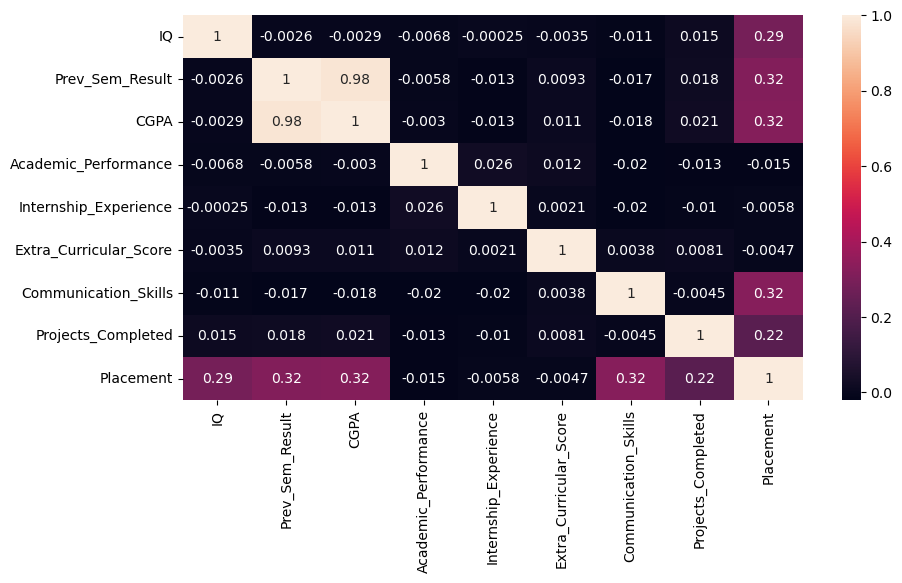

In [32]:
plt.figure(figsize=(10,5))
sns.heatmap(
     corr,
    annot= True
)
plt.show()

In [33]:
df.drop("Prev_Sem_Result", axis = 1, inplace = True)

In [34]:
df.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.28,8,0,8,8,4,0
1,97,5.37,8,0,7,8,0,0
2,109,5.83,9,0,3,1,1,0
3,122,5.75,6,1,1,6,1,0
4,96,7.69,7,0,8,10,2,0


In [35]:
X = df.drop("Placement", axis = 1)

In [36]:
y = df["Placement"]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [39]:
X_train.shape

(8000, 7)

In [40]:
y_train.shape

(8000,)

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()

In [43]:
X_train = scaler.fit_transform(X_train)

In [44]:
X_test = scaler.transform(X_test)

In [45]:
X_train.view()

array([[ 0.22949886, -0.38674212,  1.55447715, ...,  0.31852749,
         0.1526292 , -0.88477013],
       [-0.76655391, -1.70492153, -0.88091677, ..., -0.94656866,
        -0.53605303, -0.88477013],
       [-0.23532577, -0.3663579 , -0.53300335, ...,  1.2673496 ,
        -0.19171192,  0.86091247],
       ...,
       [-0.70015039, -0.5905843 , -1.57674361, ...,  1.58362364,
        -1.56907637,  1.44280667],
       [ 0.22949886,  0.02773697, -0.53300335, ...,  0.95107556,
        -0.88039414, -0.30287593],
       [-1.69620317, -0.7128896 , -0.53300335, ...,  0.95107556,
        -0.88039414, -1.46666434]], shape=(8000, 7))

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
model = LogisticRegression()

In [48]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
y_predict = model.predict(X_test)

In [50]:
comparison = pd.DataFrame({
    "Actual" : y_test,
    "Prediction": y_predict
})


In [51]:
comparison

,Actual,Prediction
6252,0,1
4684,0,0
1731,0,0
4742,0,0
4521,1,1
...,...,...
6412,0,0
8285,0,0
7853,0,1
1095,0,0


In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy_score(y_test, y_predict)

0.903

In [54]:
import joblib

In [55]:
joblib.dump(
    {
        "model": model,
        "features": X.columns.tolist()
    },
    "Placement_Prediction2.pkl"
)

['Placement_Prediction2.pkl']